In [1]:
#hack till I make it a real package..
import os

#using GPU, comment out if on CPU?
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'
os.environ['CUDA_VISIBLE_DEVICES'] = '3'
import jax 
jax.config.update('jax_disable_jit', False)
#jax.config.update("jax_debug_nans", True)

import numpy as np
import jax.numpy as jnp
import diffhydro as dh

# --------------------
# 1) Grid definition
# --------------------
eq = dh.equationmanager.EquationManager()
nx, ny, nz = 256, 256, 256               # example base grid...
Lx, Ly, Lz = 30.0, 30.0, 30.0            # kpc box covering r_max=20 kpc, z_max=3 kpc
eq.mesh_shape = [nx, ny, nz]            # 
eq.box_size  = (Lx, Ly, Lz)             #

# Uniform Cartesian cell centers
x = (np.arange(nx) + 0.5) * (Lx/nx) - Lx/2
y = (np.arange(ny) + 0.5) * (Ly/ny) - Ly/2
z = (np.arange(nz) + 0.5) * (Lz/nz) - Lz/2
X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

R = np.sqrt(X**2 + Y**2)

# --------------------
# 2) Disk parameters (MakeDisk-like)
# --------------------
# Supply these from “Disk properties” section:
M_GAS = 5.0e9       # Msun
r_d   = 3.0         # kpc
z_d   = 1.0         # kpc
r_max = 20.0        # kpc (disk truncation)
z_max = 3.0         # kpc

# Central density from the provided formula:
#   rho(r,z) = rho0 * exp(-r/r_d) * exp(-|z|/z_d)
#   rho0 = M_GAS / (4*pi*r_d^2*z_d)
rho0 = M_GAS / (4.0*np.pi*r_d**2 * z_d)

rho_disk = rho0 * np.exp(-R/r_d) * np.exp(-np.abs(Z)/z_d)

# Truncate disk outside (r_max, z_max)
disk_mask = (R <= r_max) & (np.abs(Z) <= z_max)
rho_disk *= disk_mask

# --------------------
# 3) Halo
# --------------------
# A very tenuous halo; number density ~1e-6 cm^-3 at T=1e6 K was suggested.
# Here we just set a small uniform mass density floor in code units.
rho_halo = 1e-6 * rho0
rho = rho_disk + (~disk_mask) * rho_halo

# --------------------
# 4) Temperatures & pressure (primitive p is pressure)
# --------------------
# Disk: T=1e4 K, solar Z (chemistry not tracked here; p = rho*R*T / μ)
# Halo: T=1e6 K, primordial Z, v=0
# EquationManager treats p as primitive and converts to E internally

# Choose a mean molecular weight μ (in code units this collapses into R).
mu_disk = 1.0     #
mu_halo = 1.0

T_disk = 1.0e4
T_halo = 1.0e6*3 #not sure about this number...

# the gas constant R is set to 1.0 by default (non-dimensional)
Rgas = eq.R

p = np.where(disk_mask, rho*Rgas*T_disk/mu_disk, rho*Rgas*T_halo/mu_halo)

# --------------------
# 5) Rotation curve -> azimuthal velocity field
# --------------------
# Load either "vcirc.dat" or the updated "vcirc_SPH.dat" (km/s vs kpc).
# First column: r [kpc], second: v_circ [km/s]
vcirc_path = "../../data/vcirc_SPH.dat"    # prefer the SPH-binned update 
dat = np.loadtxt(vcirc_path)
r_tab, v_tab = dat[:,0], dat[:,1]  # kpc, km/s

# Interpolate v_circ(R)
vphi = np.interp(R, r_tab, v_tab, left=v_tab[0], right=v_tab[-1])

# Map azimuthal v_phi to Cartesian components (u= vx, v= vy, w= vz) with sign convention:
# e_phi = (-y/r, +x/r, 0)
eps = 1e-30
ex = -Y / (R + eps)
ey =  X / (R + eps)
ez =  0.0

# Set velocities: disk rotates; halo is static (v=0)
u = np.where(disk_mask, vphi*ex, 0.0)
v = np.where(disk_mask, vphi*ey, 0.0)
w = np.zeros_like(u)

# --------------------
# 6) Build primitives [rho, u, v, w, p] and convert to conservatives
# --------------------
W = np.stack([rho, u, v, w, p], axis=0).astype(np.float32)
U = eq.get_conservatives_from_primitives(jnp.asarray(W))  # uses p→E internally :contentReference[oaicite:6]{index=6}

# --------------------
# 7) 
# --------------------

#WRONG AXIS!
def pressure_correct_vphi(
    W,                   # primitives [rho,u,v,w,p] with shapes (5, nx, ny[, nz])
    x, y, z=None,        # cell-center coords (same shape as rho)
    vcirc_r=None,        # 1D array radii [kpc] from vcirc file
    vcirc_v=None,        # 1D array v_circ [km/s] from vcirc file
    r_bins=None,         # optional custom bin edges for shells [kpc]
    z_cut=None,          # optional |z| cut [kpc] for midplane averaging
    eps=1e-30
):
    """
    Returns a copy of W with (u,v) replaced by pressure-corrected azimuthal velocities.
    """
    rho = np.array(W[0])
    u   = np.array(W[1])
    v   = np.array(W[2])
    w   = np.array(W[3])
    P   = np.array(W[4])  # primitives last entry is pressure in your manager

    # Geometry
    R = np.sqrt(x*x + y*y)
    if z is None:
        z = np.zeros_like(R)

    # Mask for midplane average (optional)
    mid = np.ones_like(R, dtype=bool) if z_cut is None else (np.abs(z) <= z_cut)

    # Build annular bins
    if r_bins is None:
        r_max = float(np.nanmax(R))
        nbin = 256
        r_bins = np.linspace(0.0, r_max, nbin+1)
    r_cent = 0.5*(r_bins[:-1] + r_bins[1:])

    # Bin-averaged rho(r), P(r)
    # (mass-weighted for Ω is common; here we just area-weight over cells in annulus & |z|-cut)
    rho_of_r = np.zeros_like(r_cent)
    P_of_r   = np.zeros_like(r_cent)
    for i in range(len(r_cent)):
        m = (R >= r_bins[i]) & (R < r_bins[i+1]) & mid
        if np.any(m):
            vals_rho = rho[m].ravel()
            vals_P   = P[m].ravel()
            wts      = np.ones_like(vals_rho, dtype=float)  # exact same shape
            rho_of_r[i] = np.average(vals_rho, weights=wts)
            P_of_r[i]   = np.average(vals_P,   weights=wts)
        else:
            rho_of_r[i] = np.nan
            P_of_r[i]   = np.nan

    # Clean NaNs by nearest fill
    def _fillna_nearest(arr):
        idx = np.where(np.isfinite(arr))[0]
        if idx.size == 0:
            return np.zeros_like(arr)
        out = np.interp(np.arange(arr.size), idx, arr[idx])
        return out
    rho_of_r = _fillna_nearest(rho_of_r)
    P_of_r   = _fillna_nearest(P_of_r)

    # Smooth a bit to avoid noise in dP/dr (simple moving average)
    def _smooth(y, w=3):
        if w <= 1: return y
        k = w//2
        yy = np.pad(y, (k,k), mode='edge')
        ker = np.ones(w)/w
        return np.convolve(yy, ker, mode='same')[k:-k]
    rho_of_r_s = _smooth(rho_of_r, w=5)
    P_of_r_s   = _smooth(P_of_r,   w=5)

    # Derivative dP/dr on bin centers
    dPdr = np.gradient(P_of_r_s, r_cent, edge_order=2)

    # Interpolate vcirc and dP/dr, rho to each cell radius
    if vcirc_r is None or vcirc_v is None:
        raise ValueError("Provide vcirc_r and vcirc_v from 'vcirc_SPH.dat' (r [kpc], v [km/s]).")
    v_circ_cell = np.interp(R, vcirc_r, vcirc_v, left=vcirc_v[0], right=vcirc_v[-1])

    dPdr_cell   = np.interp(R, r_cent, dPdr, left=dPdr[0], right=dPdr[-1])
    rho_cell    = np.interp(R, r_cent, rho_of_r_s, left=rho_of_r_s[0], right=rho_of_r_s[-1])

    # Pressure support term: r * (1/rho) * dP/dr
    corr = R * (dPdr_cell / np.maximum(rho_cell, eps))

    # Build corrected vphi; enforce non-negative under the root
    vphi_sq = np.maximum(v_circ_cell*v_circ_cell + corr, 0.0)
    vphi    = np.sqrt(vphi_sq)

    # Map azimuthal v_phi onto Cartesian (u,v): e_phi = (-y/r, +x/r)
    ex = np.where(R > 0, -y/(R+eps), 0.0)
    ey = np.where(R > 0,  x/(R+eps), 0.0)

    u_new = vphi * ex
    v_new = vphi * ey

    # Write back into a new primitives array, preserve w and p
    W_new = np.array(W, copy=True)
    W_new[1] = u_new
    W_new[2] = v_new
    W_new[3] = w     # unchanged
    W_new[4] = P     # unchanged
    return W_new


In [2]:
r_tab.shape,v_tab.shape

((2000,), (2000,))

In [3]:
W_corr = pressure_correct_vphi(W, x, y, z,
                               vcirc_r=r_tab, vcirc_v=v_tab,
                               z_cut=0.6)      # e.g., z_cut = 2*z_d

U_corr = eq.get_conservatives_from_primitives(jnp.asarray(W_corr))  # uses p→E internally :contentReference[oaicite:6]{index=6}


%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


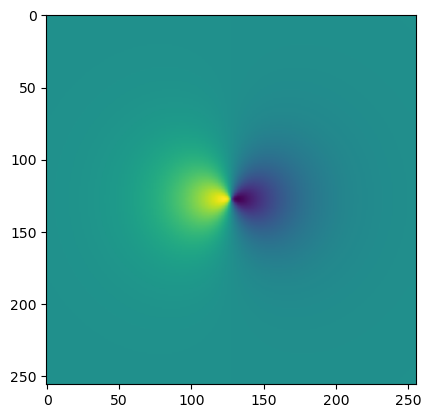

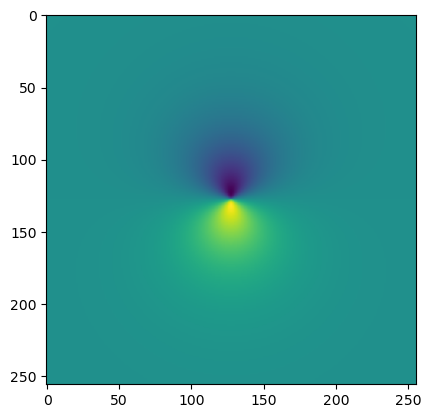

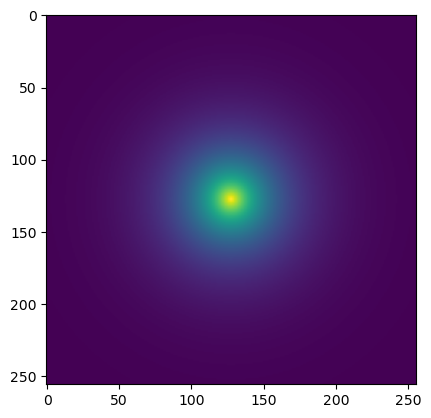

In [4]:
%pylab inline
imshow(U[1][:,:,127])
show()
imshow(U[2][:,:,127])
show()
imshow(U[0][:,:,127])

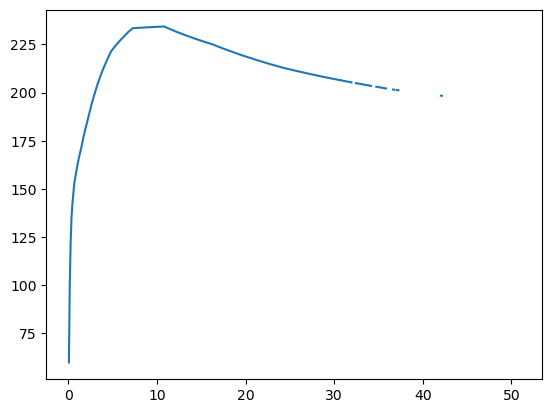

In [5]:
plt.plot(r_tab,v_tab)

In [6]:
grav = dh.physics.gravity.FFTSelfGravityForce(eq, G=1E-12, subtract_mean=True)  

In [ ]:
import copy
ss = dh.signal_speed_Rusanov
solver = dh.HLLC(equation_manager=eq, signal_speed=ss)
cf = dh.ConvectiveFlux(eq, solver, dh.MUSCL3(limiter="VANLEER"))
grav = dh.physics.gravity.FFTSelfGravityForce(eq, G=5E-6, subtract_mean=True)  

hydro = dh.hydro(
    n_super_step=10000,
    fluxes=[cf],
    forces=[grav],
    integrator='SSPRK3',
    snapshot_every = 100)

state = hydro.evolve_with_callbacks(copy.deepcopy(U), params={})


In [72]:
hydro.sim_time

1.5059350728988647

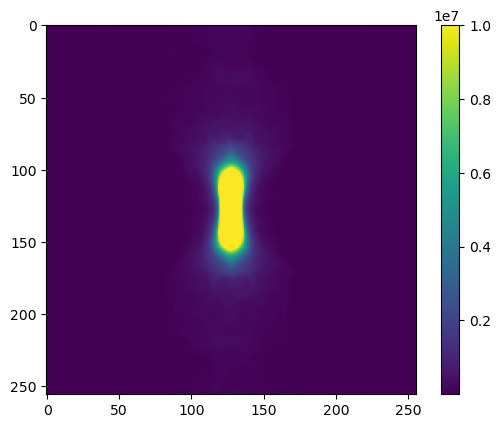

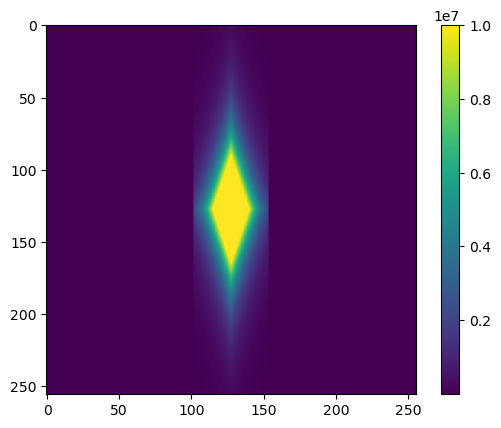

In [73]:
imshow(state[0][0][128],vmax=1E7)
colorbar()
show()
imshow(U[0][128],vmax=1E7)
colorbar()

show()

Shard shape: (5, 256, 256, 256)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


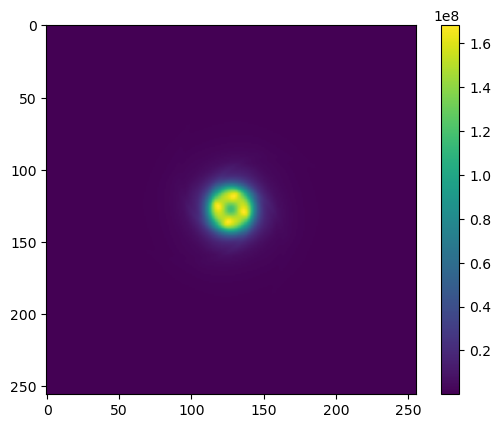

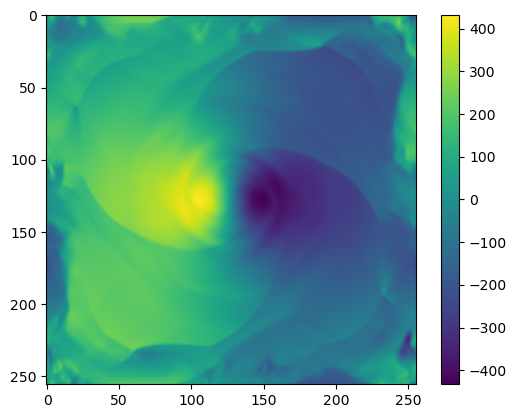

Shard shape: (5, 256, 256, 256)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


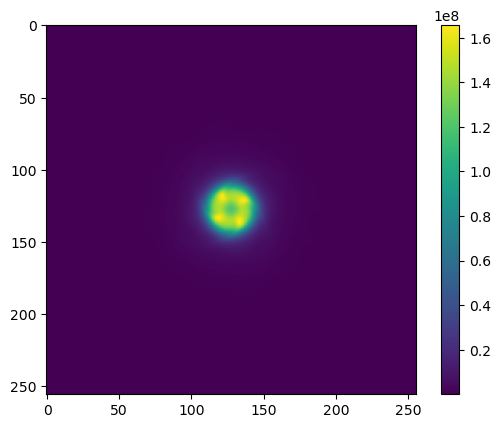

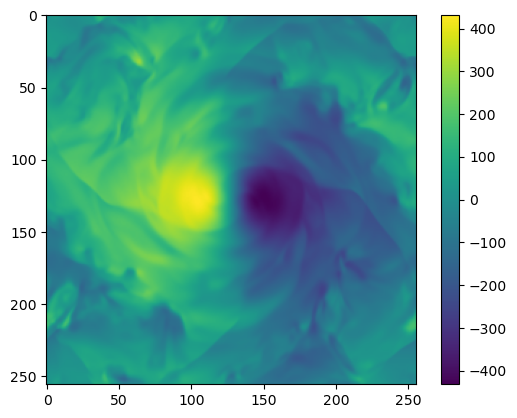

In [74]:
from diffhydro.utils.io import shard_snaps

rr = shard_snaps.load_snapshot(hydro,8000)
imshow(rr[0][:,:,128])
colorbar()
show()

imshow(rr[1][:,:,128]/rr[0][:,:,128])
colorbar()
show()


rr = shard_snaps.load_snapshot(hydro,9900)
imshow(rr[0][:,:,128])
colorbar()
show()


imshow(rr[1][:,:,128]/rr[0][:,:,128])
colorbar()
show()

Shard shape: (5, 256, 256, 256)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


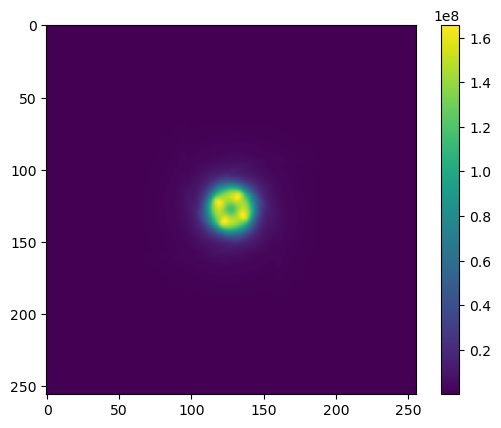

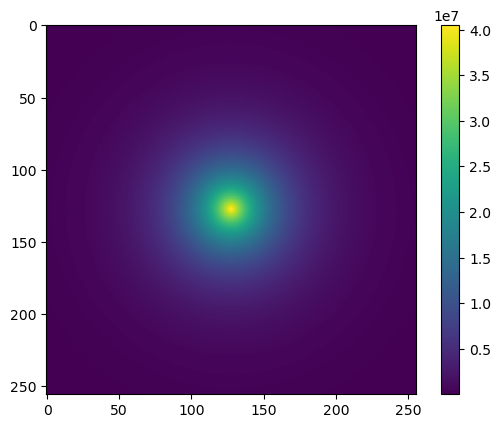

In [75]:

rr = shard_snaps.load_snapshot(hydro,8600)
imshow(rr[0][:,:,128])
colorbar()
show()
imshow(U[0][:,:,128])
colorbar()

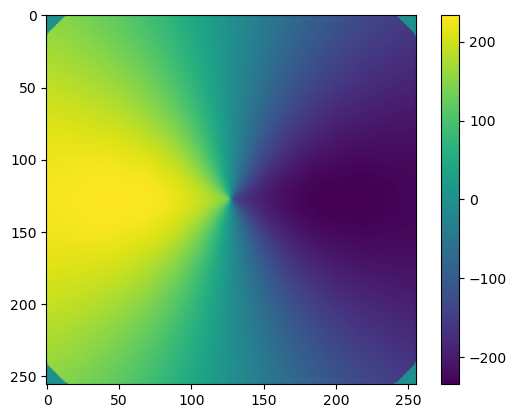

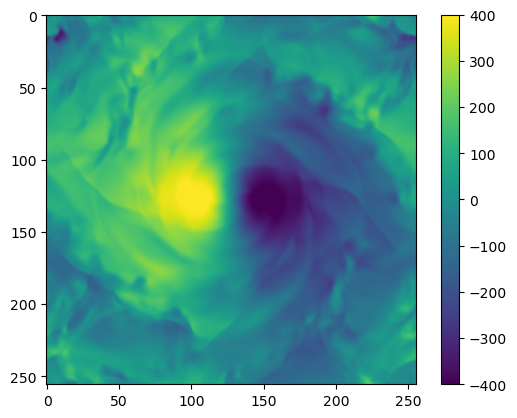

In [76]:
#velocity profile
imshow(U[1][:,:,128]/U[0][:,:,128])
colorbar()
show()
imshow(state[0][1][:,:,128]/state[0][0][:,:,128],vmin=-400,vmax=400)
colorbar()
show()

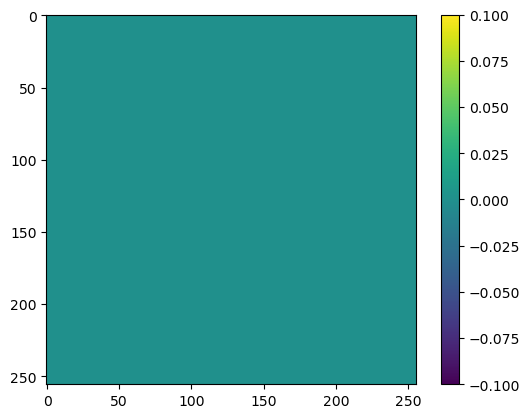

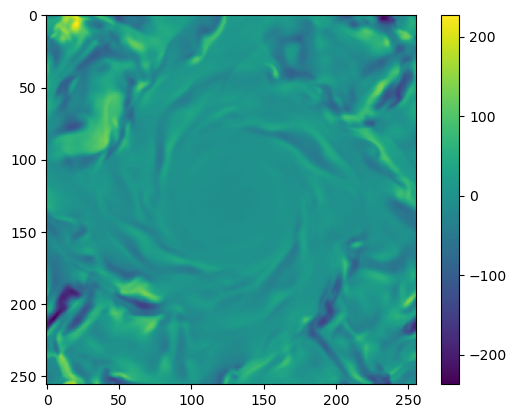

In [77]:
imshow(U[3][:,:,128]/U[0][:,:,128])
colorbar()
show()
imshow(state[0][3][:,:,128]/state[0][0][:,:,128])
colorbar()
show()

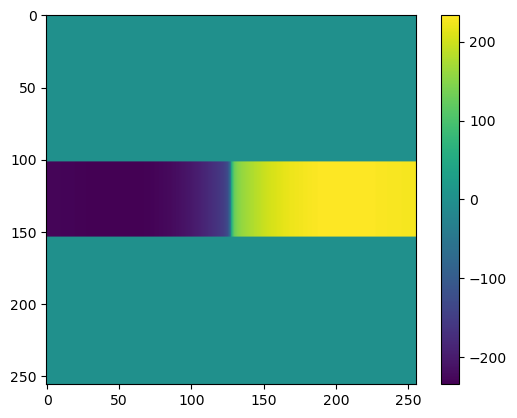

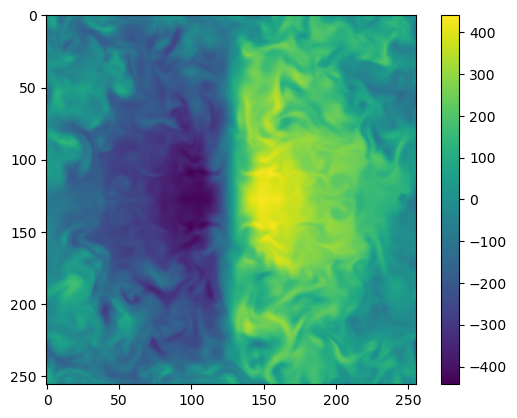

In [78]:
imshow((U[2][:,128]/U[0][:,128]).T)
colorbar()
show()
imshow((state[0][2][:,128]/state[0][0][:,128]).T)
colorbar()
show()

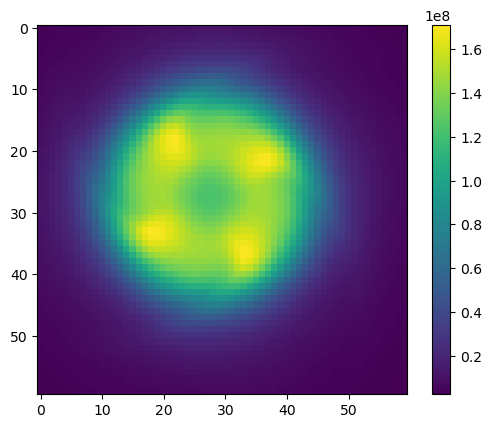

In [79]:
imshow((state[0])[0][100:160,100:160,128])
colorbar()

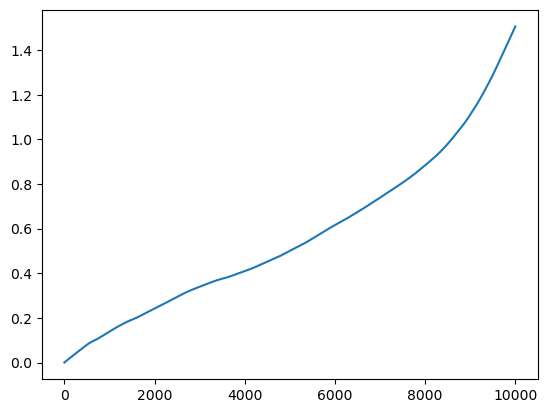

In [80]:
#timestep plot...
plt.plot(np.cumsum(state[-1]))

Shard shape: (5, 256, 256, 256)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


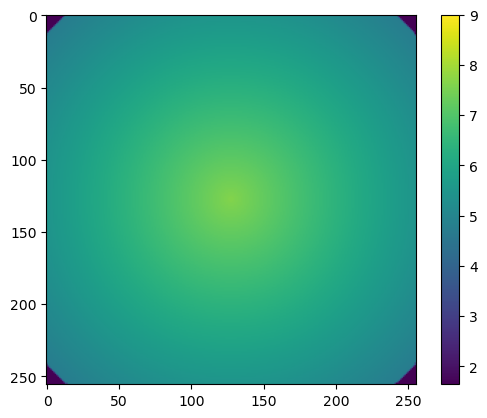

Shard shape: (5, 256, 256, 256)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


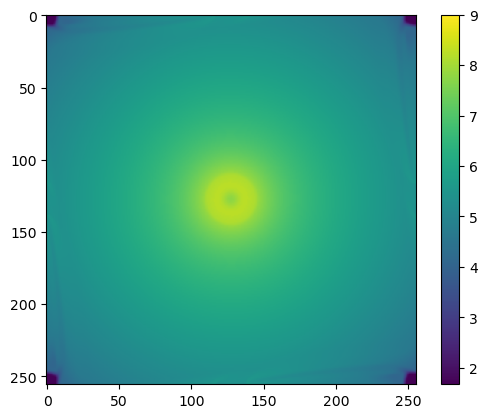

Shard shape: (5, 256, 256, 256)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


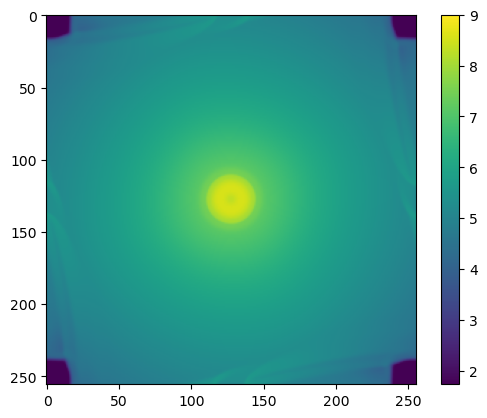

Shard shape: (5, 256, 256, 256)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


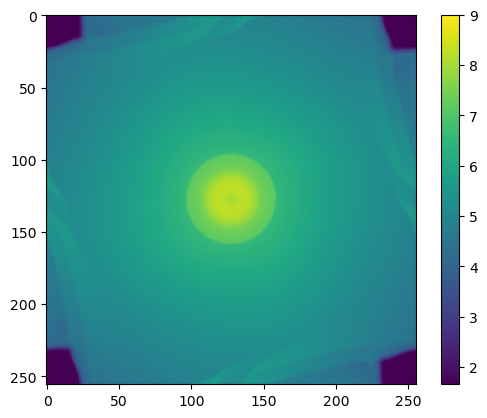

Shard shape: (5, 256, 256, 256)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


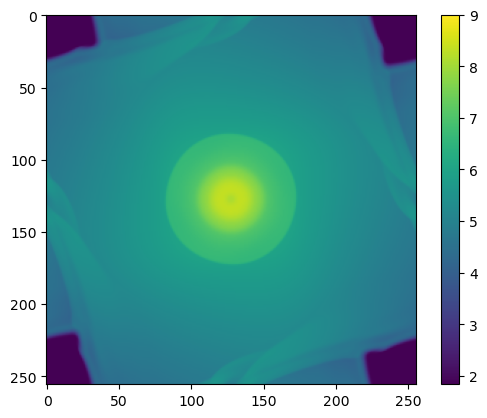

Shard shape: (5, 256, 256, 256)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


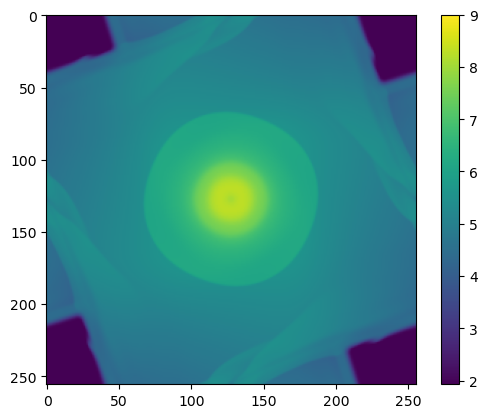

Shard shape: (5, 256, 256, 256)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


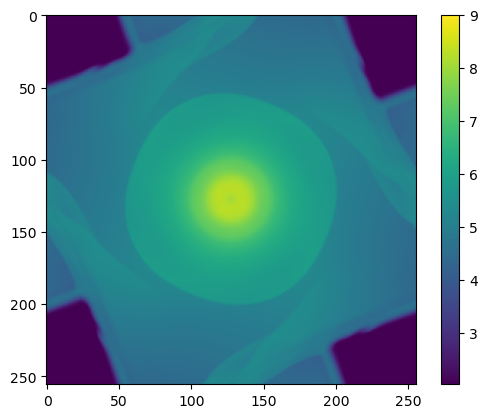

Shard shape: (5, 256, 256, 256)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


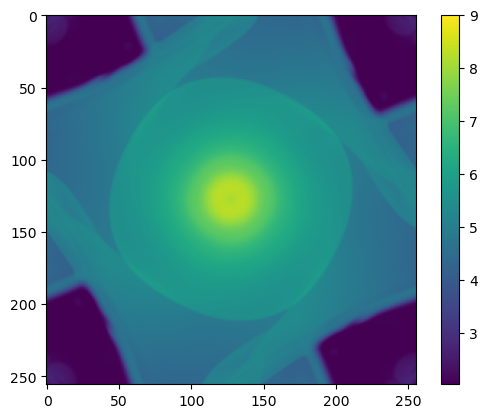

Shard shape: (5, 256, 256, 256)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


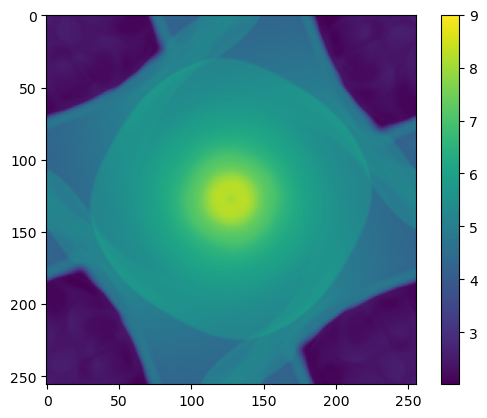

Shard shape: (5, 256, 256, 256)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


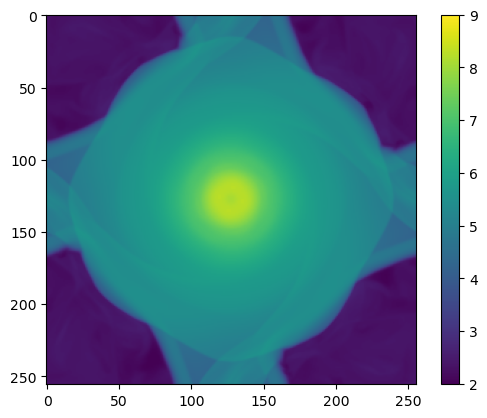

Shard shape: (5, 256, 256, 256)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


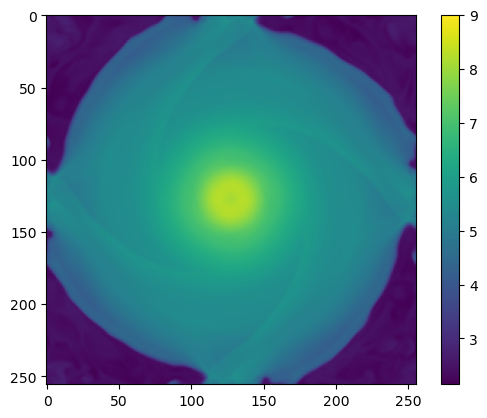

Shard shape: (5, 256, 256, 256)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


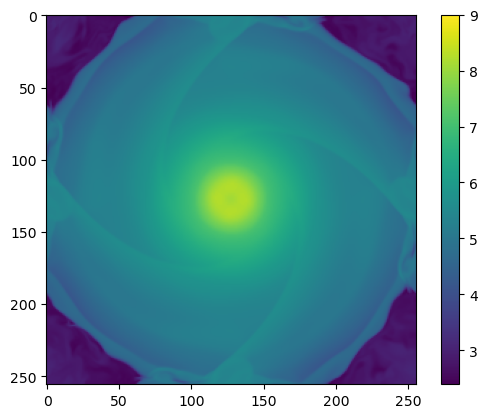

Shard shape: (5, 256, 256, 256)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


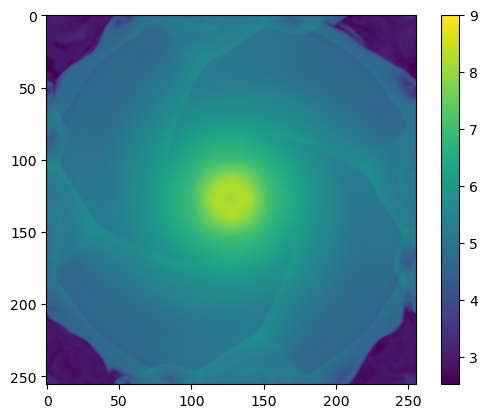

Shard shape: (5, 256, 256, 256)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


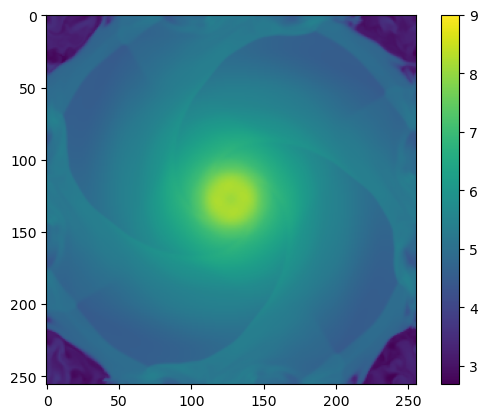

Shard shape: (5, 256, 256, 256)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


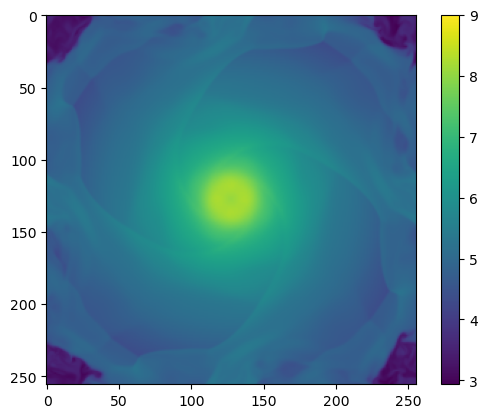

Shard shape: (5, 256, 256, 256)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


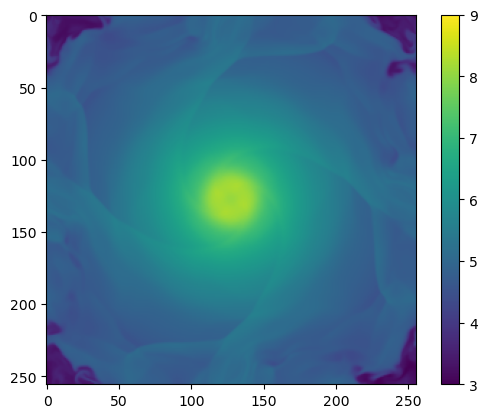

In [51]:
for i in range(0,8*2):
    rr = shard_snaps.load_snapshot(hydro,i*500)
    imshow(np.log10(rr[0][:,:,128]),vmax=9)
    colorbar()
    show()